In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016")

print("Path to dataset files:", path)

100%|██████████| 70.6M/70.6M [00:00<00:00, 172MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016/versions/1


In [5]:
import kagglehub

path = kagglehub.dataset_download(
"waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016"
)

print(path)

Using Colab cache for faster access to the 'gene-expression-cancer-rna-seq-donated-on-682016' dataset.
/kaggle/input/gene-expression-cancer-rna-seq-donated-on-682016


In [6]:
import os
os.listdir(path)

['data.csv', 'labels.csv']

In [7]:
import pandas as pd
import os

data = pd.read_csv(os.path.join(path, "data.csv"))
labels = pd.read_csv(os.path.join(path, "labels.csv"))

print(data.shape)
print(labels.shape)

(801, 20532)
(801, 2)


In [8]:
print(data.head())

  Unnamed: 0  gene_0    gene_1    gene_2    gene_3     gene_4  gene_5  \
0   sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0   
1   sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0   
2   sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0   
3   sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0   
4   sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0   

     gene_6    gene_7  gene_8  ...  gene_20521  gene_20522  gene_20523  \
0  7.175175  0.591871     0.0  ...    4.926711    8.210257    9.723516   
1  6.816049  0.000000     0.0  ...    4.593372    7.323865    9.740931   
2  6.972130  0.452595     0.0  ...    5.125213    8.127123   10.908640   
3  7.843375  0.434882     0.0  ...    6.076566    8.792959   10.141520   
4  6.566967  0.360982     0.0  ...    5.996032    8.891425   10.373790   

   gene_20524  gene_20525  gene_20526  gene_20527  gene_20528  gene_20529  \
0    7.220030    9.119813   12.003135  

In [9]:
print(labels.head())

  Unnamed: 0 Class
0   sample_0  PRAD
1   sample_1  LUAD
2   sample_2  PRAD
3   sample_3  PRAD
4   sample_4  BRCA


In [10]:
print(labels.columns)

Index(['Unnamed: 0', 'Class'], dtype='object')


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(labels['Class'])

print(y[:10])

[4 3 4 4 0 4 2 4 0 4]


In [12]:
X = data
print(X.shape)

(801, 20532)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

print(X_train.shape)
print(X_test.shape)

(640, 20532)
(161, 20532)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(20532,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(len(set(y)), activation='softmax'))

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     2,628,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,636,805 (10.06 MB)

 Trainable params: 2,636,805 (10.06 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
print(data.dtypes)

Unnamed: 0     object
gene_0        float64
gene_1        float64
gene_2        float64
gene_3        float64
               ...   
gene_20526    float64
gene_20527    float64
gene_20528    float64
gene_20529    float64
gene_20530    float64
Length: 20532, dtype: object


In [18]:
data = data.drop('Unnamed: 0', axis=1)
print(data.shape)

(801, 20531)


In [19]:
X = data

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
input_shape=(20531,)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(20531,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(len(set(y)), activation='softmax'))

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     2,628,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,636,677 (10.06 MB)

 Trainable params: 2,636,677 (10.06 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
X_train,
y_train,
epochs=30,
batch_size=32,
validation_split=0.2
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8457 - loss: 0.7615 - val_accuracy: 0.9844 - val_loss: 0.0988
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9629 - loss: 0.3115 - val_accuracy: 1.0000 - val_loss: 3.7488e-05
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9766 - loss: 0.1192 - val_accuracy: 0.9922 - val_loss: 0.0393
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9844 - loss: 0.1955 - val_accuracy: 0.9922 - val_loss: 0.0609
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9844 - loss: 0.1801 - val_accuracy: 0.9922 - val_loss: 0.0653
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9902 - loss: 0.0639 - val_accuracy: 0.9922 - val_loss: 0.0475
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9941 - loss: 0.0719 - val_accuracy: 0.9922 - val_loss: 0.0753
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9961 - loss: 0.1484 - val_accuracy: 0.9922

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0000e+00 
Test Accuracy: 1.0


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


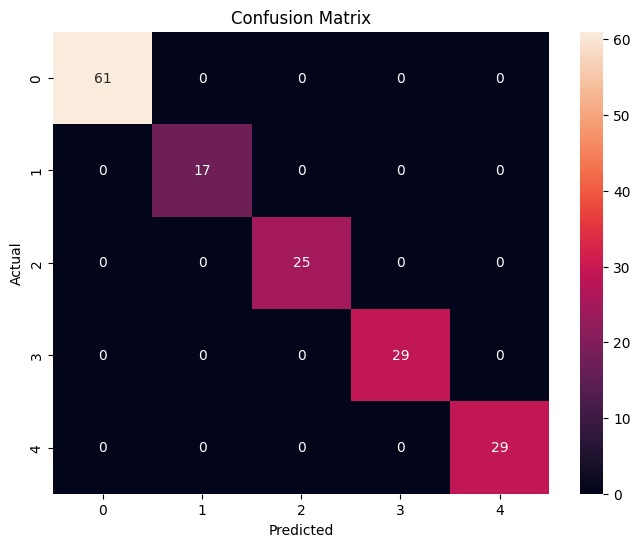

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        29
           4       1.00      1.00      1.00        29

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



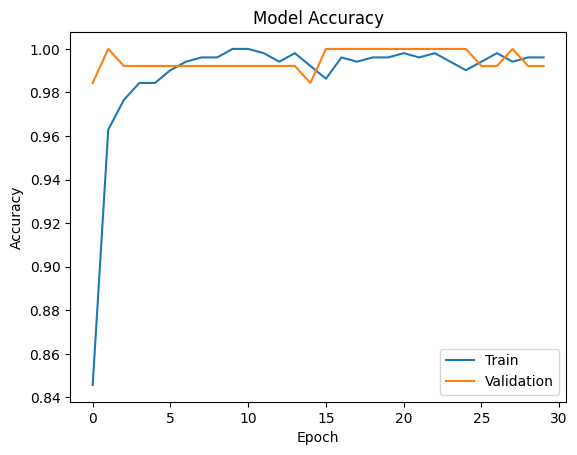

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

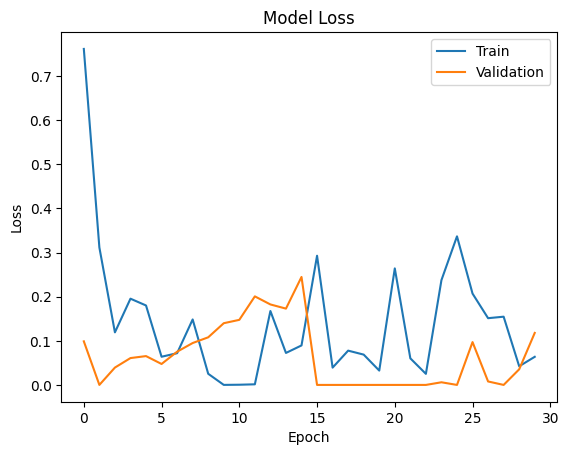

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [30]:
model.save("gene_expression_cancer_model.h5")
print("Model Saved Successfully")

Model Saved Successfully


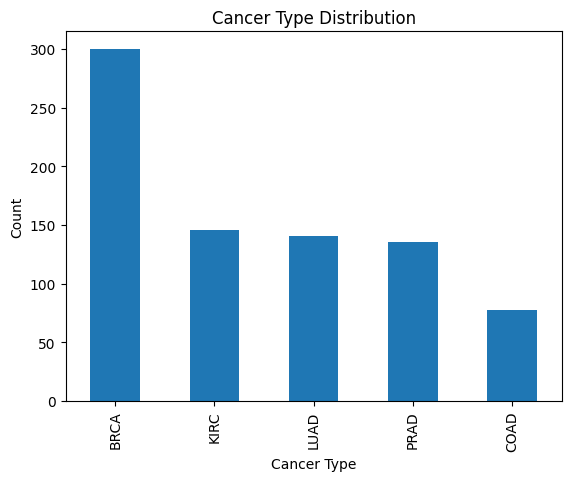

In [31]:
labels['Class'].value_counts().plot(kind='bar')
plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.show()

In [32]:
print("""
PROJECT COMPLETED

Gene Expression Cancer Classification using Deep Learning

Results:
- Training Accuracy: 99.6%
- Validation Accuracy: 99.2%
- Test Accuracy: 100%

The model successfully classified cancer types using
gene expression RNA-Seq data and achieved excellent performance.
""")


PROJECT COMPLETED

Gene Expression Cancer Classification using Deep Learning

Results:
- Training Accuracy: 99.6%
- Validation Accuracy: 99.2%
- Test Accuracy: 100%

The model successfully classified cancer types using
gene expression RNA-Seq data and achieved excellent performance.

